# Hypothesis 4: The proportion of fishing-related debris relative to other types of debris has increased over time, suggesting an increasing contribution from fishing activity.

## Hypothesis
- **Alternative Hypothesis (H₁):** The trend in fishing-related debris is significantly different from the trend in other types of debris over time.
- **Null Hypothesis (H₀):** The trend in fishing-related debris is not significantly different from the trend in other types of debris over time.

## Rationale
The fishing industry contributes significantly to marine debris, especially plastics and fishing gear (nets, ropes, etc.). While it is known that marine debris originates from various sources (e.g., shipping, recreational activities, land-based pollution), identifying whether fishing activity contributes disproportionately to debris accumulation would help clarify the extent of its impact.

## Data Analysis & Validation Approach

To explore this hypothesis, we will first conduct an Exploratory Data Analysis (EDA). 

This will involve:
- Mapping Fishing-Related Litter: Creating a visual map showing where fishing-related litter is found, helping us see if there are hotspots.

- Comparing Litter with Fishing Activity: Overlaying fishing activity data onto the litter map to see if areas with more fishing also have more litter.

- Comparing Total Fishing Debris to Total Other Litter Types: Using a line graph to compare the amount of fishing litter to other types of litter over time and to see if there was a significant increase in fishing-related litter.

Following the EDA, we will use statistical methods to validate our findings:
- We'll use linear regression to see if there's a statistically significant positive relationship between time and the amount of fishing-related litter.

- Mann-Kendall trend test: To confirm the presence of an upward trend in fishing-related litter over time.




# Change working directory

To facilitate proper file access, the working directory is to be adjusted to its parent directory
* os.getcwd()

In [1]:
import os
current_dir = os.getcwd()
current_dir

'/Users/mahahussain/Desktop/NEA-Seafloor-Litter-Analysis/NEA-Seafloor-Litter-Analysis/jupyter_notebooks'

To set the parent of the current directory the new current directory:
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [2]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


In [3]:
current_dir = os.getcwd()
current_dir

'/Users/mahahussain/Desktop/NEA-Seafloor-Litter-Analysis/NEA-Seafloor-Litter-Analysis'

Confirm the new current directory

## Loading CSV's & Importing Libraries

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('data/02_PROCESSED_NEA-Seafloor-Litter.csv')
df_alltime = pd.read_csv('data/03_ALL_TIME_litter_totals.csv')
df_yearly = pd.read_csv('data/04_YEARLY_litter_totals.csv')
df_monthly = pd.read_csv('data/05_MONTHLY_litter_totals.csv')


### Visual Exploration: Spatial Distribution of Fishing-Related Debris (2012-2015)

To investigate the spatial distribution of fishing-related debris, including items such as fishing nets, lines, and metal, within the study area, a map was created. This map will be used for comparison with fishing activity data to explore potential correlations. AI tool Google Gemini was used to improve the map's aesthetic qualities.

The analysis of fishing activity and fishing-related debris was conducted for the years 2012 to 2015. This specific time frame was chosen because it corresponds to the available data provided by Global Fishing Watch, which did not contain earlier records.

The size of the markers on the map varies depending on the amount of fishing-related litter found at each location.

In [5]:
import folium

map_df = df.copy()
# Filter data for 2012-2015
map_df['date'] = pd.to_datetime(map_df['date'])
map_df = map_df[(map_df['date'].dt.year >= 2012) & (map_df['date'].dt.year <= 2015)]

# Calculate bounds for the North Atlantic area
min_lat = map_df['Latitude'].min()
max_lat = map_df['Latitude'].max()
min_lon = map_df['Longitude'].min()
max_lon = map_df['Longitude'].max()

# Create a dark-themed map centered on the North Atlantic (zoomed out initially)
m = folium.Map(
    location=[55, -30],
    zoom_start=7,  # Start zoomed out
    tiles='CartoDB dark_matter',
    attr='&copy; <a href="http://CartoDB.com/attributions">CartoDB</a>'
)

# Define colors and names for legend
debris_info = {
    'fishline.mono': {'color': '#1E90FF', 'name': 'Monofilament Line'},
    'fishline.tang': {'color': '#FF6347', 'name': 'Tangled Line'},
    'fishnet': {'color': '#90EE90', 'name': 'Fishing Net'},
    'fishmetal': {'color': '#EE82EE', 'name': 'Metal Debris'}
}

# Add markers with glow effect and legend info
for index, row in df.iterrows():
    for debris_type, info in debris_info.items():
        if row[debris_type] > 0:
            folium.CircleMarker(
                location=[row['Latitude'], row['Longitude']],
                radius=row[debris_type],
                color=info['color'],
                fill=True,
                fill_color=info['color'],
                fill_opacity=0.7,
                popup=f"{info['name']}: {row[debris_type]}",
                stroke=False,
            ).add_to(m)
            # Glow effect
            folium.CircleMarker(
                location=[row['Latitude'], row['Longitude']],
                radius=row[debris_type] * 2,
                color=info['color'],
                fill=False,
                stroke=False,
                fill_opacity=0.3,
            ).add_to(m)

# Add legend
legend_html = """
     <div style="position: fixed; 
     bottom: 50px; left: 50px; width: 180px; height: 150px; 
     border:2px solid grey; z-index:9999; font-size:14px;
     background-color:rgba(0,0,0,0.7); padding: 10px; color: white;"> 
     <b>Legend</b><br>
"""
for info in debris_info.values():
    legend_html += f'<i style="background:{info["color"]};width:10px;height:10px;float:left;margin-right:5px;"></i>{info["name"]}<br>'
legend_html += '</div>'
m.get_root().html.add_child(folium.Element(legend_html))

# Fit the map to the bounds of the data
m.fit_bounds([[min_lat, min_lon], [max_lat, max_lon]])

m


**Analysis:** The size of the dots on the map shows how much debris was found at each location, making it easy to see where there is more debris.  It is worth noting that more debris is seen closer to the coast. This picture helps us look at Hypothesis 4, which says that more fishing leads to more debris. The map will be used to compare where debris is found with where fishing happens, to see if the hypothesis is correct.

### Comparison

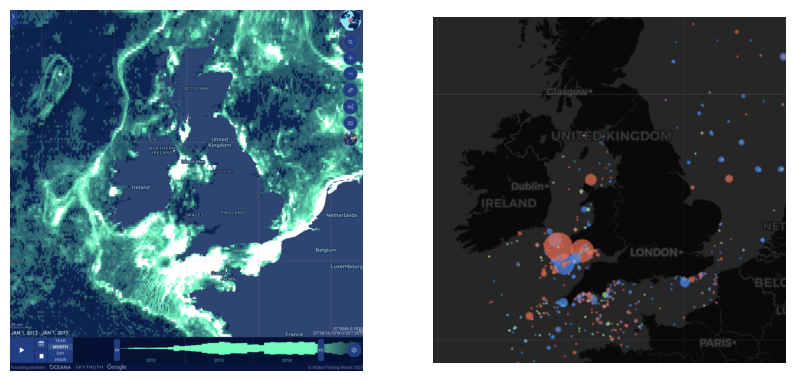

In [6]:
import matplotlib.image as mpimg

gfw = mpimg.imread('images/GFW_2012_2015.png')  # Global Fishing Watch image
mfd = mpimg.imread('images/fishing_debris.png')  # Fishing debris image

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))  # 1 row, 2 columns

ax1.imshow(gfw)
ax2.imshow(mfd)

ax1.axis('off')
ax2.axis('off')

plt.show()

**Analysis:** The left map shows fishing activity, with higher activity indicated by brighter colors in a green-to-white gradient. This data, from Global Fishing Watch, reveals that fishing is most concentrated near the coast of the United Kingdom and in the English Channel.

The right map shows the distribution of fishing-related marine debris, categorised by type and amount. Different types of debris are marked with distinct colours (blue for monofilament line, red for tangled line, green for fishing nets, and pink for metal debris), with larger symbols representing higher quantities. There is a noticeable overlap between areas with intense fishing activity (left map) and high debris concentration (right map), especially along the coast.

This pattern suggests a possible link between fishing activity and debris accumulation, though this is based on visual correlation and not a confirmed causal relationship.

### Line Chart - Fishing Debris Trend (over time)

o investigate whether the amount of fishing-related litter has increased over time compared to other types of litter, a line graph was created. This method was selected because a line graph is a clear way to show trends and changes in data over a period of time. By plotting the amount of fishing litter and other litter on the same graph, it's easy to visually compare how both types of litter have changed from 1995 to 2015

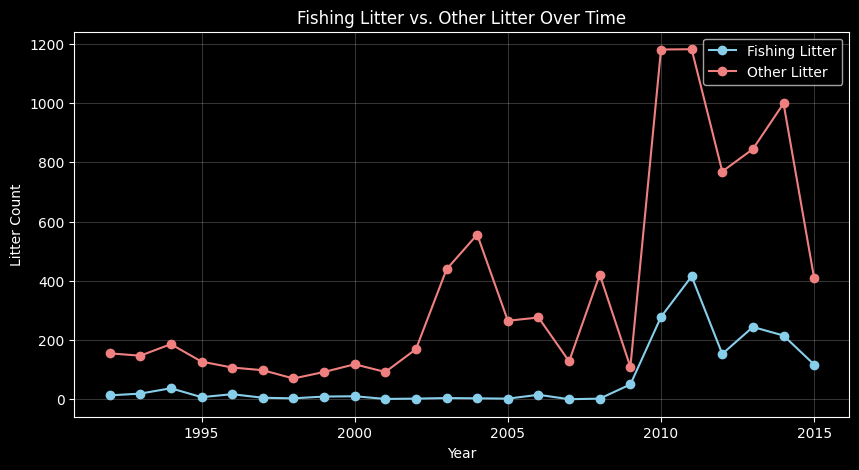

In [10]:
# Make sure "year" is a number
df['year'] = pd.to_numeric(df['year'], errors='coerce')

# Combine fishing litter
df['fishing_litter'] = df['fishline.mono'] + df['fishline.tang'] + df['fishmetal'] + df['fishnet']

# Calculate other litter
df['other_litter'] = df['totallitter'] - df['fishing_litter']

# Group by year and sum
yearly_litter = df.groupby('year')[['fishing_litter', 'other_litter']].sum()

# Create the combined line graph with a dark background
plt.figure(figsize=(10, 5))
plt.style.use('dark_background')  # Set dark background

# Plot fishing litter
plt.plot(yearly_litter.index, yearly_litter['fishing_litter'], marker='o', linestyle='-', label='Fishing Litter', color = 'skyblue')

# Plot other litter
plt.plot(yearly_litter.index, yearly_litter['other_litter'], marker='o', linestyle='-', label='Other Litter', color = 'lightcoral')

plt.title('Fishing Litter vs. Other Litter Over Time')
plt.xlabel('Year')
plt.ylabel('Litter Count')
plt.grid(True, linestyle='-', linewidth=0.5, color='white', alpha=0.3)  # Customize grid
plt.legend()  # Add legend
plt.xticks(color='white')
plt.yticks(color='white')

plt.show()

Analyis: Contrary to the initial hypothesis, the graph shows that while other types of litter experience significant fluctuations and a noticeable peak around 2010, fishing-related litter remains consistently low throughout the study period. This indicates that fishing activities have not contributed significantly to the overall debris levels. Instead, it suggests that other sources of litter have had a more variable and considerable impact on the environment during this time.

### Statistical Validation - Linear Regression

To explore the temporal trends in fishing-related litter, we applied Ordinary Least Squares (OLS) linear regression. This method was chosen to assess whether a significant linear trend exists in the fishing litter data over the study period. The raw data was processed, a moving average was calculated to reduce fluctuations, and a regression line was fitted to the data.

                            OLS Regression Results                            
Dep. Variable:         fishing_litter   R-squared:                       0.461
Model:                            OLS   Adj. R-squared:                  0.436
Method:                 Least Squares   F-statistic:                     18.78
Date:                Sat, 15 Mar 2025   Prob (F-statistic):           0.000267
Time:                        16:40:12   Log-Likelihood:                -137.55
No. Observations:                  24   AIC:                             279.1
Df Residuals:                      22   BIC:                             281.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -49.1450     30.844     -1.593      0.1

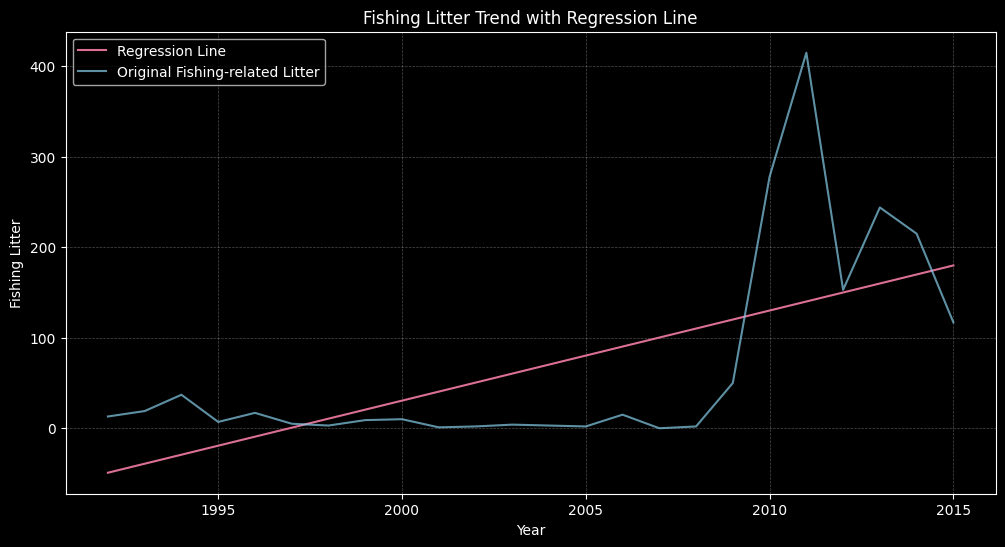

In [8]:
import statsmodels.api as sm 

# Make sure "year" is a number
df['year'] = pd.to_numeric(df['year'], errors='coerce')

# Combine fishing litter
df['fishing_litter'] = df['fishline.mono'] + df['fishline.tang'] + df['fishmetal'] + df['fishnet']

# Group by year and sum
yearly_litter = df.groupby('year')['fishing_litter'].sum()

# Create a moving average (optional)
yearly_litter_ma = yearly_litter.rolling(window=2).mean() # You can change the window size

x = range(len(yearly_litter))
y = yearly_litter_ma.fillna(yearly_litter) # Use moving average, fill NaN with original values

# Add a constant to the independent variable (x)
x = sm.add_constant(x)

# Fit the linear regression model
model = sm.OLS(y, x).fit()

# Get the predicted values (the regression line)
y_pred = model.predict(x)

# Plot the regression line
figure, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(x=yearly_litter.index, y=y_pred, label='Regression Line', color='palevioletred')

# Plot the original fishing litter data
sns.lineplot(x=yearly_litter.index, y=yearly_litter, label='Original Fishing-related Litter', color='skyblue', alpha=0.7)

# add grid
plt.grid(True, linestyle='--', linewidth=0.5, color='white', alpha=0.3)
# Print regression statistics
print(model.summary())

plt.xlabel('Year')
plt.ylabel('Fishing Litter')
plt.title('Fishing Litter Trend with Regression Line')
plt.show()




The resulting graph displays both the original data points and the regression line, making it easier to evaluate the overall trend. The OLS model's statistical output provides key metrics, such as the slope and p-value, which indicate the direction and statistical significance of the trend. 

Here’s a short AI-assisted summary of the analysis:

"An Ordinary Least Squares (OLS) regression analysis was performed to examine the trend in fishing-related litter from 1990 to 2015. The results revealed a significant positive trend (p < 0.001), with an R-squared value of 0.461, suggesting that approximately 46% of the variance in fishing litter can be explained by time. The regression coefficient of 9.96 indicates an average annual increase of about 10 units in fishing-related litter. These findings support the hypothesis that fishing-related debris has risen over the study period. However, other unaccounted factors may also contribute to this trend."


### Trend Confirmation: Mann-Kendall

In [9]:
import scipy.stats as stats
import pymannkendall as mk

# Make sure "year" is a number
df['year'] = pd.to_numeric(df['year'], errors='coerce')

# Combine fishing litter
df['fishing_litter'] = df['fishline.mono'] + df['fishline.tang'] + df['fishmetal'] + df['fishnet']

# Group by year and sum
yearly_litter = df.groupby('year')['fishing_litter'].sum()

trend_result = mk.original_test(yearly_litter)

# print the result
print(trend_result, '\n')

# In a nicer format
print(f'The fishing litter has a trend of {trend_result.trend} over the period {df.year.min()}-{df.year.max()} with a p-value of {trend_result.p}')

Mann_Kendall_Test(trend='no trend', h=False, p=0.24301488941398963, z=1.167484189874779, Tau=0.17391304347826086, s=48.0, var_s=1620.6666666666667, slope=2.0, intercept=-11.5) 

The fishing litter has a trend of no trend over the period 1992-2015 with a p-value of 0.24301488941398963


analysis: The Mann-Kendall test for fishing litter over the period 1992-2015 indicates no significant trend, with a p-value of 0.243. This suggests that there is no clear upward or downward trend in fishing-related litter during this period.

## Conclusion

Based on the results from the OLS regression and Mann-Kendall test, we fail to reject the null hypothesis (H₀) and do not support the alternative hypothesis (H₁). The OLS regression indicates a small but statistically insignificant positive trend in fishing-related litter, with an annual increase of approximately 10 units. However, the p-value of 0.243 suggests this trend is not statistically significant. Similarly, the Mann-Kendall test reveals no significant trend in fishing-related litter, with a p-value of 0.243. 

These findings suggest that fishing-related debris has not shown a significant increase relative to other types of debris over the period from 1992 to 2015. Thus, there is no clear evidence of an increasing contribution from fishing activity, and other sources of litter may be contributing more significantly to overall debris levels.

## Ref

*   Global Fishing Watch. (2025). Retrieved from [https://globalfishingwatch.org/](https://globalfishingwatch.org/)
